# The AMAT model in NESTML

This notebook guides you through writing the Augmented Multi-adaptive Threshold (AMAT) model in NESTML, and runs basic simulations and characterisations of the model. We first validate the numerical results, perform a parameter space exploration, and then use the AMAT model in a balanced network.

In [1]:
%matplotlib inline

from typing import Literal, Mapping, Sequence

from dataclasses import dataclass
import dataclasses
import importlib
import matplotlib.pyplot as plt
import nest
import numpy as np
from pathlib import Path
import sys

import pynestml

from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils
from pynestml.codegeneration.nest_tools import NESTTools


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Apr 15 2026 13:28:55

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## Introduction to the AMAT model

[... plug in dynamical equations of AMAT model, add citations ...]

## Formulating the model in NESTML

See the file ``amat_neuron.nestml`` in the neuron models directory (https://github.com/nest/nestml/blob/...)

In [2]:
# generate and build code
module_name, nestml_neuron_model_name = \
    NESTCodeGeneratorUtils.generate_code_for("../../../models/neurons/amat_neuron.nestml",
                                             logging_level="DEBUG")    # XXX change to "WARNING"
nest.Install(module_name)

[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /home/charl/julich/nestml-upstream/nestml/doc/tutorials/amat_model/../../../models/neurons/amat_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: "/home/charl/julich/nestml-upstream/nestml/doc/tutorials/amat_model/target"
[4,GLOBAL, INFO]: Target platform code will be installed in directory: "/tmp/nestml_target_x1hlnhfd"

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Apr 15 2026 13:28:55

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: main
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with default templates directory "/home/charl/jul

[ODE-toolbox] INFO:Analysing input:
[ODE-toolbox] INFO:{
    "dynamics": [
        {
            "expression": "V_th_alpha_1' = (-V_th_alpha_1) / tau_1",
            "initial_values": {
                "V_th_alpha_1": "0"
            }
        },
        {
            "expression": "V_th_alpha_2' = (-V_th_alpha_2) / tau_2",
            "initial_values": {
                "V_th_alpha_2": "0"
            }
        },
        {
            "expression": "V_m' = ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "V_th_v_aux' = (-V_th_v_aux) / tau_v + beta * ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_th_v_aux": "0 / 1.0"
       

[ODE-toolbox] INFO:Analysing input:
[ODE-toolbox] INFO:{
    "dynamics": [
        {
            "expression": "V_th_alpha_1' = (-V_th_alpha_1) / tau_1",
            "initial_values": {
                "V_th_alpha_1": "0"
            }
        },
        {
            "expression": "V_th_alpha_2' = (-V_th_alpha_2) / tau_2",
            "initial_values": {
                "V_th_alpha_2": "0"
            }
        },
        {
            "expression": "V_m' = ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "V_th_v_aux' = (-V_th_v_aux) / tau_v + beta * ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_th_v_aux": "0 / 1.0"
       

[11,GLOBAL, INFO]: Starting code generation for model "amat_neuron_nestml"
[12,amat_neuron_nestml, INFO, [124:0;229:0]]: Starts processing of the model "amat_neuron_nestml"
[13,GLOBAL, INFO]: Rendering template /home/charl/julich/nestml-upstream/nestml/doc/tutorials/amat_model/target/amat_neuron_nestml.cpp
[14,GLOBAL, INFO]: Rendering template /home/charl/julich/nestml-upstream/nestml/doc/tutorials/amat_model/target/amat_neuron_nestml.h
[15,amat_neuron_nestml, INFO, [124:0;229:0]]: Successfully generated code for the model: "amat_neuron_nestml" in: "/home/charl/julich/nestml-upstream/nestml/doc/tutorials/amat_model/target" !
[16,GLOBAL, INFO]: Rendering template /home/charl/julich/nestml-upstream/nestml/doc/tutorials/amat_model/target/nestml_9da726c6586e42b5baa4b9551f8aef2b_module.cpp
[17,GLOBAL, INFO]: Rendering template /home/charl/julich/nestml-upstream/nestml/doc/tutorials/amat_model/target/nestml_9da726c6586e42b5baa4b9551f8aef2b_module.h
[18,GLOBAL, INFO]: Rendering template /home

## Numerical validation of the NESTML AMAT model 



In [32]:
nest_model = "amat2_psc_exp"
nestml_source = Path("../../../models/neurons/amat_neuron.nestml")
resolution_ms = 0.5


Building dataclass configs for NESTML and NEST models, with `Frozen=True` and `Literal[]` so the data and variables cannot be influenced and affected in downstream simulations

For instance, mismatch in NESTML, NEST:
- NESTML expects that offset directly: `omega = 5 mV`.
- Native NEST exposes `omega` as the **absolute threshold** in its status dictionary, so the equivalent value is `E_L + 5 mV = -65 mV`.

The native model records `V_th` as an absolute voltage. The NESTML model now records the same absolute threshold directly. Native NEST records `I_syn_ex` and `I_syn_in` separately, so total `I_syn` is their sum. Discrete differences that affect the comparision in the output 


In [38]:
# restricts so only modeltype can be the following 
ModelType = Literal["nest", "nestml"]

@dataclass(frozen=True) # pass AMATConfig into both nestml and nest configs, ensures params are kept the same 
class AMATConfig:
    pulse_times_ms: tuple[float] = (10., 30., 210., 270.)
    pulse_amplitude_pa: float = 1000.0
    pulse_width_ms: float = 1.0
    simulation_time_ms: float = 400.0
  
    tau_m_ms: float = 10.0
    gamma: float = 1.5
    B: float = 4.0
    
    E_L_mv = -70.0
    resting_threshold_mv = -65.0
    
    alpha_1_mv: float = 10.0
    alpha_2_mv: float = 0.0

@dataclass
class SimulationResult: # 
    model_name: str
    ModelType: ModelType
    events: Mapping
    spikes: Mapping
    parameters: dict[str, float]
    
    
def create_step_current(
    pulse_times_ms: Sequence[float],
    pulse_width_ms: float,
    pulse_amplitude_pa: float,
):
    """Create a rectangular pulse train using one step-current generator."""
    amplitude_times: list[float] = []
    amplitude_values: list[float] = []

    for onset in pulse_times_ms:
        amplitude_times.extend([onset, onset + pulse_width_ms])
        amplitude_values.extend([pulse_amplitude_pa, 0.0])

    return nest.Create(
        "step_current_generator",  # input config for injecting I(e) into the neuron 
        params={
            "amplitude_times": amplitude_times,    # pulse params are stored in the public API  
            "amplitude_values": amplitude_values,    
        },
    )


def identify_model_type(model_name: str, nestml_model_name: str = None) -> ModelType: 
    if "nestml" in model_name:
        return "nestml"
    return "nest"
#     if model_name == nest_model:
#         return "nest"   # classifying what model we are running for the specified sim
#     if model_name == nestml_model_name:
#         return "nestml"
#     raise ValueError(f"Unsupported AMAT model: {model_name}")


def build_model_parameters(
    model_name: str,
    ModelType: ModelType,
    config: AMATConfig,
) -> dict[str, float]:
    """Translate shared conceptual parameters to each model's public API."""   # public API has a frozen set of params?
    defaults = nest.GetDefaults(model_name)
    tau_m = float(defaults["tau_m"])

    return {
        "tau_m": tau_m,
        "tau_v": config.gamma * tau_m, 
        "beta": config.B / tau_m,
        "alpha_1": config.alpha_1_mv,
        "alpha_2": config.alpha_2_mv,
        "omega": config.resting_threshold_mv,
    }


# available and selected recordables may have different names dep on the nestml/nest config soruce of mismatch errors 
def select_recordables(model_name: str, requested: Sequence[str]) -> list[str]:
    """Keep only quantities actually exposed by the selected model."""
    
    available = set(nest.GetDefaults(model_name)["recordables"])   # collect the recordables available at the nest terminal 
    
    selected = [name for name in requested if name in available]
    missing = [name for name in requested if name not in available]
    
    if missing:
        print(f"{model_name}: unavailable recordables omitted: {missing}")

    return selected

def reconstruct_spike_kernel(times,
                             spike_times,
                             alpha, 
                             tau):
    
    # converting the inputs into NumPy arrays of decimal numbers to guarantee fast mathematical operations.
    times = np.asarray(times, dtype=float)
    spike_times = np.asarray(spike_times, dtype=float)
    result = np.zeros_like(times)

    for spike_time in spike_times:
        mask = times >= spike_time # loops through each individual spike timestamp one by one to calculate its contribution to the overall signal.
        result[mask] += (alpha * np.exp(-(times[mask] - spike_time) / tau))
        # Creates a filter of True and False values. applying the timepoint to the exact timepoint 
        
    return result 


def derive_traces(events, spikes, params, config, model_kind):
    """
    Return the same trace dictionary for native NEST and generated NESTML.

    Generated NESTML:
        alpha_1, alpha_2, theta_v, theta_v_aux are recorded directly.

    Native NEST:
        V_th is treated as relative threshold.
        alpha_1 and alpha_2 are reconstructed from output spikes.
        theta_v_aux is approximated from recorded theta_v.
    """
    times = np.asarray(events["times"])
    V_m = np.asarray(events["V_m"])
    spike_times = np.asarray(spikes["times"])

    zeros = np.zeros_like(V_m)

    omega = params["omega"]
    alpha_1 = params["alpha_1"]
    alpha_2 = params["alpha_2"]
    tau_1 = params["tau_1"]
    tau_2 = params["tau_2"]
    tau_v = params["tau_v"]
    E_L = config.E_L

    if model_kind == "nestml":
        theta_alpha_1 = np.asarray(events.get("V_th_alpha_1", zeros))
        theta_alpha_2 = np.asarray(events.get("V_th_alpha_2", zeros))
        theta_v = np.asarray(events.get("V_th_v", zeros))
        theta_v_aux = np.asarray(events.get("V_th_v_aux", zeros))

        theta_relative = omega + theta_alpha_1 + theta_alpha_2 + theta_v
        theta_absolute = E_L + theta_relative

    elif model_kind == "native":
        raw_V_th = np.asarray(events["V_th"])

        # Native NEST AMAT appears to record V_th as a relative threshold.
        theta_relative = raw_V_th
        theta_absolute = E_L + theta_relative

        theta_v = np.asarray(events.get("V_th_v", zeros))

        theta_alpha_1 = reconstruct_spike_kernel(
            times=times,
            spike_times=spike_times,
            alpha=alpha_1,
            tau=tau_1,
        )

        theta_alpha_2 = reconstruct_spike_kernel(
            times=times,
            spike_times=spike_times,
            alpha=alpha_2,
            tau=tau_2,
        )

        # Approximate the hidden auxiliary state from theta_v.
        # This is a derived diagnostic, not a true native NEST recordable.
        dt = np.mean(np.diff(times))
        dtheta_v_dt = np.gradient(theta_v, dt)
        theta_v_aux = theta_v / tau_v + dtheta_v_dt

    else:
        raise ValueError("model_kind must be 'nestml' or 'native'.")

    distance = V_m - theta_absolute

    return {
        "times": times,
        "V_m": V_m,
        "theta_absolute": theta_absolute,
        "theta_relative": theta_relative,
        "theta_alpha_1": theta_alpha_1,
        "theta_alpha_2": theta_alpha_2,
        "theta_v": theta_v,
        "theta_v_aux": theta_v_aux,
        "distance": distance,
        "spike_times": spike_times,
    }

def run_amat_model(
    model_name: str,
    nestml_model_name: str,
    module_name: str,
    config: AMATConfig,
    *,  #  When you see a bare asterisk * by itself in a function definition, it marks the end of positional arguments and the start of keyword-only arguments
    verbose: bool = True,  #  default verbose true 
) -> SimulationResult:
    """Run one AMAT implementation using the shared experiment definition."""
    
    nest.ResetKernel() # each time an AMAT mdoel is ran reset kernel, clean slate with any pre-existing param values etc. 
    nest.SetKernelStatus({"resolution": resolution_ms})
    nest.Install(module_name)

    if model_name not in nest.Models():
        raise RuntimeError(f"Model is not loaded: {model_name}")

    model_type = identify_model_type(model_name, nestml_model_name) # utilising helper functions defined in the cell above 
    parameters = build_model_parameters(model_name, model_type, config)
    neuron = nest.Create(model_name, params=parameters)

    current = create_step_current(
        config.pulse_times_ms,
        config.pulse_width_ms,
        config.pulse_amplitude_pa,
    )
    nest.Connect(current, neuron)

    spike_recorder = nest.Create("spike_recorder") 
    nest.Connect(neuron, spike_recorder)

    requested_recordables = [ # request all recordables and see what's available? 
        "V_m",
        "V_th",
        "V_th_alpha_1",
        "V_th_alpha_2",
        "V_th_v",
        "V_th_v_aux",
        "I_syn_ex",
        "I_syn_in",
        "I_syn",
    ]
    recordables = select_recordables(model_name, requested_recordables)

    multimeter = nest.Create( # connect all avaialbe recordables to the multimeter 
        "multimeter",
        params={
            "interval": resolution_ms,
            "record_from": recordables,
        },
    )
    
    nest.Connect(multimeter, neuron) # connect multi meter to neuron 
    nest.Simulate(config.simulation_time_ms) # sim

    events = multimeter.get("events")
    spikes = spike_recorder.get("events")

    result_parameters = {
        **parameters,
        "gamma": config.gamma,
        "B": config.B,
        "E_L": config.E_L_mv, # result parameters for plotting and dispaly 
        "resting_threshold": config.resting_threshold_mv,
    }

    if verbose:   # In simulation scripts, it is typically a boolean flag. verbose=true, outputs whereas verbose=false quiet mode 
        print(f"\n{model_name}")
        print("Parameters sent to NEST:", parameters)
        print("Recorded variables:", recordables)
        print("Spike times:", np.asarray(spikes["times"]))
        print(
            "V_m range:",
            f"{np.min(events['V_m']):.6f} to {np.max(events['V_m']):.6f} mV",
        )

    return SimulationResult(
        model_name=model_name,
        ModelType=model_type,
        events=events,
        spikes=spikes,
        parameters=result_parameters,
    )

def get_recordables(model_kind):
    if model_kind == "native":
        return ["V_m", "V_th", "V_th_v", "I_syn_ex"]

    if model_kind == "nestml":
        return [
            "V_m",
            "V_th_alpha_1",
            "V_th_alpha_2",
            "V_th_v",
            "V_th_v_aux",
        ]

    raise ValueError("model_kind must be 'native' or 'nestml'.")


def simulate_amat(model_name, model_kind, config, module_name=None, verbose=True):
    """
    Run one AMAT simulation and return an AMATRun object.
    """
    nest.ResetKernel()
    nest.Install(module_name)
    if module_name is not None:
        try:
            nest.Install(module_name)
        except Exception:
            pass

    defaults = nest.GetDefaults(model_name)

    tau_m = defaults["tau_m"]
    tau_v = config.gamma * tau_m
    beta = config.B / tau_m

    params = {
        "omega": config.omega,
        "alpha_1": config.alpha_1,
        "alpha_2": config.alpha_2,
        "beta": beta,
        "tau_v": tau_v,
        "tau_m": tau_m,
        "gamma": config.gamma,
        "B": config.B,
        "tau_1": defaults.get("tau_1", 10.0),
        "tau_2": defaults.get("tau_2", 200.0),
    }

    neuron_params = {
        "omega": params["omega"],
        "alpha_1": params["alpha_1"],
        "alpha_2": params["alpha_2"],
        "beta": params["beta"],
        "tau_v": params["tau_v"],
    }

    neuron = nest.Create(model_name, params=neuron_params)

    current = make_pulse_current(
        pulse_times=config.pulse_times,
        pulse_width=config.pulse_width,
        pulse_amplitude=config.pulse_amplitude,
    )

    nest.Connect(current, neuron)

    sr = nest.Create("spike_recorder")
    nest.Connect(neuron, sr)

    mm = nest.Create(
        "multimeter",
        params={
            "interval": 0.1,
            "record_from": get_recordables(model_kind),
        },
    )

    nest.Connect(mm, neuron)
    nest.Simulate(config.simtime)

    events = mm.get("events")
    spikes = sr.get("events")

    traces = derive_traces(
        events=events,
        spikes=spikes,
        params=params,
        config=config,
        model_kind=model_kind,
    )

    run = AMATRun(
        model_name=model_name,
        model_kind=model_kind,
        config=config,
        params=params,
        events=events,
        spikes=spikes,
        traces=traces,
    )

    if verbose:
        print(f"\n--- {model_kind.upper()} AMAT: {model_name} ---")
        print("params:", params)
        print("spikes:", spikes["times"])
        print("V_m range:", np.min(traces["V_m"]), np.max(traces["V_m"]))
        print("theta range:", np.min(traces["theta_absolute"]), np.max(traces["theta_absolute"]))
        print("distance range:", np.min(traces["distance"]), np.max(traces["distance"]))

    return run

In [39]:

def reconstruct_input_current(
    times_ms: np.ndarray,
    config: AMATConfig,
) -> np.ndarray:
    """
    Reconstruct the commanded step current for plotting.

    This is the known input supplied to the neuron, rather than a current
    recorded from the neuron itself.
    """
    times_ms = np.asarray(times_ms)
    current = np.zeros_like(times_ms, dtype=float)

    for onset in config.pulse_times_ms:
        active = (
            (times_ms >= onset)
            & (times_ms < onset + config.pulse_width_ms)
        )
        current[active] = config.pulse_amplitude_pa

    return current


def standardise_result(
    result: SimulationResult,
    config: AMATConfig,
) -> dict[str, np.ndarray]:
    """
    Convert native NEST and generated NESTML outputs into one shared format.

    Any variable that is unavailable in a model is represented by a zero
    array with the same length as V_m. This allows the plotting code to use
    the same keys for both implementations.
    """
    events = result.events

    times = np.asarray(events["times"])
    V_m = np.asarray(events["V_m"])
    zeros = np.zeros_like(V_m, dtype=float)

    # Synaptic-current names differ between implementations.
    I_syn_ex = np.asarray(events.get("I_syn_ex", zeros))
    I_syn_in = np.asarray(events.get("I_syn_in", zeros))
    I_syn = np.asarray(
        events.get("I_syn", I_syn_ex + I_syn_in)
    )

    # Threshold components exposed by the NESTML implementation.
    theta_alpha_1 = np.asarray(
        events.get("V_th_alpha_1", zeros)
    )
    theta_alpha_2 = np.asarray(
        events.get("V_th_alpha_2", zeros)
    )
    theta_v = np.asarray(
        events.get("V_th_v", zeros)
    )
    theta_v_aux = np.asarray(
        events.get("V_th_v_aux", zeros)
    )

    if "V_th" in events:
        # Native NEST exposes the total threshold directly.
        theta = np.asarray(events["V_th"])
    else:
        # Generated NESTML exposes separate threshold components.
        threshold_offset = (
            config.resting_threshold_mv - config.E_L_mv
        )

        theta = (
            config.E_L_mv
            + threshold_offset
            + theta_alpha_1
            + theta_alpha_2
            + theta_v
        )

    spike_times = np.asarray(
        result.spikes.get("times", []),
        dtype=float,
    )

    return {
        "times": times,
        "input_current": reconstruct_input_current(times, config),
        "V_m": V_m,
        "theta": theta,
        "distance": V_m - theta,
        "V_th_alpha_1": theta_alpha_1,
        "V_th_alpha_2": theta_alpha_2,
        "V_th_v": theta_v,
        "V_th_v_aux": theta_v_aux,
        "I_syn_ex": I_syn_ex,
        "I_syn_in": I_syn_in,
        "I_syn": I_syn,
        "spike_times": spike_times,
    }

# Comparison between NEST and NESTML 

Both AMAT models now receive the same pulse times, pulse width, pulse amplitude, simulation resolution and AMAT parameters.

For checks, plot error across time to see the difference.

In [40]:
def compare_trace( # compare trace function, taking in two traces 
    name: str,
    left: np.ndarray,
    right: np.ndarray,
) -> dict[str, float]:
    
    if left.shape != right.shape:
        raise ValueError(
            f"{name}: incompatible shapes {left.shape} and {right.shape}" # incompabile trace to compare 
        )

    error = right - left
    metrics = {
        "max_abs_error": float(np.max(np.abs(error))),
        "mean_abs_error": float(np.mean(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(error**2))),
        "error": error
    }

    print( # 6g = standard format, 12s format strings to a fixed width of 12 characters
        f"{name:12s} | "
        f"max |Δ|={metrics['max_abs_error']:.6g} | "  # maximum offset found across timepoints 
        f"MAE={metrics['mean_abs_error']:.6g} | "  # mean across the timepoints this will catch anyoffset
        f"RMSE={metrics['rmse']:.6g}" # squares every error value before averging them and taking the sqr root, penalises large deviations
    )
    return metrics

config = AMATConfig() # establish amat config 

native_result = run_amat_model(
    nest_model,
    nestml_neuron_model_name,
    module_name,
    config,
)

nestml_result = run_amat_model(
    nestml_neuron_model_name,
    nestml_neuron_model_name,
    module_name,
    config,
)

native = standardise_result(native_result, config)
print("Native NEST simulation finished.")
generated = standardise_result(nestml_result, config)
print("NESTML simulation finished.") 

native["V_th_alpha_1"] = reconstruct_spike_kernel(
    times=native["times"],
    spike_times=native["spike_times"],
    alpha=native_result.parameters["alpha_1"],
    tau=nest.GetDefaults(nest_model)["tau_1"],
)

native["V_th_alpha_2"] = reconstruct_spike_kernel(
    times=native["times"],
    spike_times=native["spike_times"],
    alpha=native_result.parameters["alpha_2"],
    tau=nest.GetDefaults(nest_model)["tau_2"],
)

assert np.allclose(native["times"], generated["times"])

comparison_metrics = {
    name: compare_trace(name, native[name], generated[name])
    for name in ["V_m", "theta", "V_th_v", "I_syn"]
}

print("\nSpike times")
print("Native :", np.asarray(native_result.spikes["times"]))
print("NESTML :", np.asarray(nestml_result.spikes["times"]))

# Plotting error across time (Cleaned Single-Column Layout)
times = native["times"]
variables_to_plot = ["V_m", "theta", "V_th_v"]


[INFO] [2026-08-05 23:32:43] Default for delta_tau changed from 0.1 to 0.5 ms
[INFO] [2026-08-05 23:32:43] Temporal resolution changed from 0.1 to 0.5 ms.
[INFO] [2026-08-05 23:32:43] loaded module nestml_9da726c6586e42b5baa4b9551f8aef2b_module
amat2_psc_exp: unavailable recordables omitted: ['V_th_alpha_1', 'V_th_alpha_2', 'V_th_v_aux', 'I_syn']

amat2_psc_exp
Parameters sent to NEST: {'tau_m': 10.0, 'tau_v': 15.0, 'beta': 0.4, 'alpha_1': 10.0, 'alpha_2': 0.0, 'omega': -65.0}
Recorded variables: ['V_m', 'V_th', 'V_th_v', 'I_syn_ex', 'I_syn_in']
Spike times: [272.]
V_m range: -70.000000 to -64.597928 mV
[INFO] [2026-08-05 23:32:43] Preparing 4 nodes for simulation.
[INFO] [2026-08-05 23:32:43] Number of local nodes: 4
Simulation time (ms): 400
Number of OpenMP threads: 1
Not using MPI

amat_neuron_nestml
Parameters sent to NEST: {'tau_m': 10.0, 'tau_v': 15.0, 'beta': 0.4, 'alpha_1': 10.0, 'alpha_2': 0.0, 'omega': -65.0}
Recorded variables: ['V_m', 'V_th', 'V_th_alpha_1', 'V_th_alpha_2'

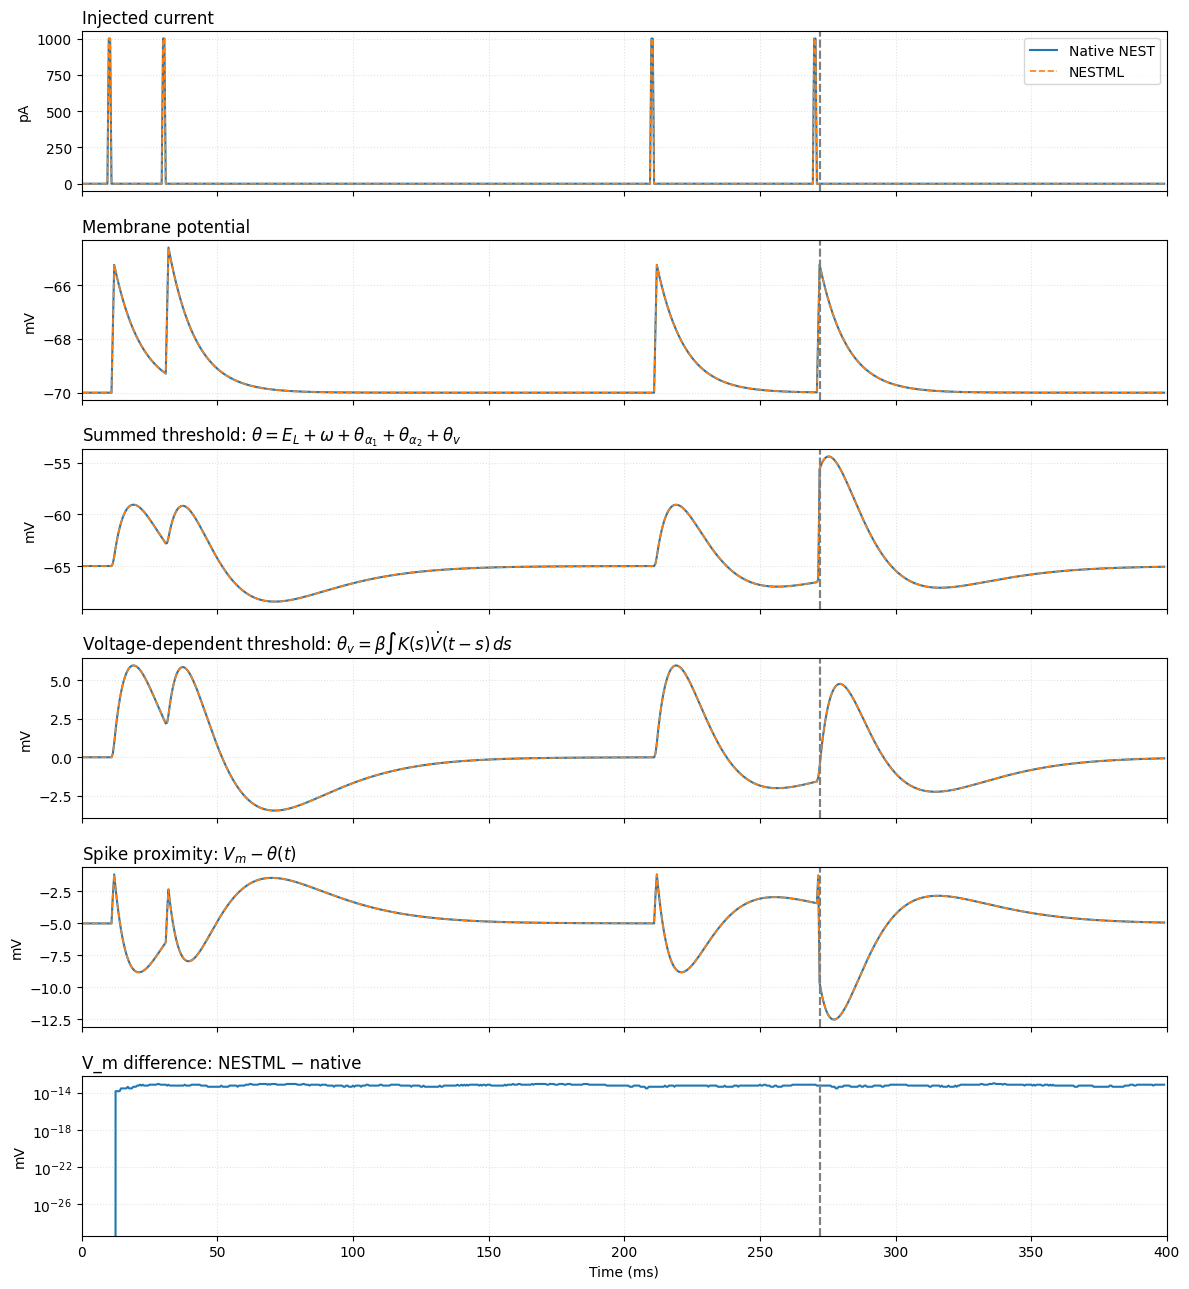

In [41]:
def plot_model_comparison_overlap(
    native: Mapping[str, np.ndarray],
    generated: Mapping[str, np.ndarray],
    *,
    xlim: tuple[float, float] | None = None,
):
    
    trace_info = [
        ("input_current", "Injected current", "pA"),  # key, title, unit
        ("V_m", "Membrane potential", "mV"),
        ("theta", r"Summed threshold: $\theta=E_L+\omega+\theta_{\alpha_1}+\theta_{\alpha_2}+\theta_v$", "mV"),
        ("V_th_v", r"Voltage-dependent threshold: $\theta_v=\beta \int K(s)\dot{V}(t-s)\,ds$", "mV"),    
        ("distance", r"Spike proximity: $V_m-\theta(t)$", "mV"),
    ]

    fig, axes = plt.subplots(
        len(trace_info) + 1,
        1,
        figsize=(12, 13),
        sharex=True,
    )

    time = native["times"]

    for ax, (key, title, unit) in zip(axes[:-1], trace_info):
        ax.plot(time, native[key], label="Native NEST", linewidth=1.5)
        ax.plot(
            time,
            generated[key],
            "--",
            label="NESTML",
            linewidth=1.2,
        )
        ax.set_ylabel(unit)
        ax.set_title(title, loc="left")
        ax.grid(True, linestyle=":", alpha=0.35)

    difference = generated["V_m"] - native["V_m"]
    axes[-1].plot(time, difference)
    axes[-1].axhline(0.0, linestyle=":", linewidth=1.0)
    axes[-1].set_title("V_m difference: NESTML − native", loc="left")
    axes[-1].set_yscale("log")
    axes[-1].set_ylabel("mV")
    axes[-1].set_xlabel("Time (ms)")
    axes[-1].grid(True, linestyle=":", alpha=0.35)

#     if xlim is not None:
#         axes[-1].set_xlim(*xlim)

    for ax in axes:
        ax.set_xlim(0, AMATConfig.simulation_time_ms)
        ax.axvline(np.asarray(native_result.spikes["times"]), color="gray", linestyle="--")
        ax.axvline(np.asarray(nestml_result.spikes["times"]), color="gray", linestyle="--")
        
    axes[0].legend()
    fig.tight_layout()
    return fig, axes

plot_model_comparison_overlap(native, generated)
plt.show()

## "Resonator" vs. "Integrator" Dynamics in the AMAT Model

This section investigates and validates the characteristics of resonators versus integrators using the AMAT NESTML model. 

Difference between integrator vs. resonator PSC behaviour:
    
- Integrator Behaviour (All-Pass): Acts like a leaky bucket. It accumulates (sums up) all incoming inputs over time, regardless of their timing. It fires a spike when the total input volume exceeds the threshold. It acts as a low-pass filter, favoring high-frequency bursts or closely packed inputs.
- Resonator Behaviour (Band-Pass): Acts like a swing. It is highly sensitive to the specific **timing** and **frequency** of inputs. It prefers a specific inter-pulse interval ($\Delta$). If a second pulse arrives at the peak of the internal oscillation caused by the first pulse, the system "resonates" and triggers a spike. If the timing is off, the inputs cancel out.

These firing behaviours are depicted in the figure below

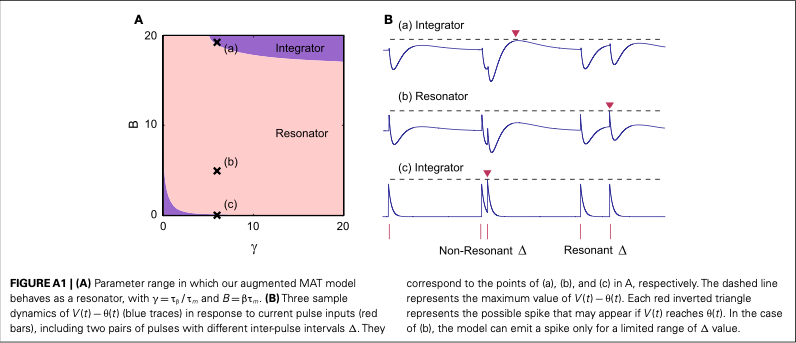


To investigate this, ... Each simulation contains two identical current pulses. The first pulse occurs at 200 ms and the second at `200 + delta` ms. We measure the largest post-pulse distance `V_m - theta`, whether a spike occurred, and the number of spikes.

The same sweep function is used for native NEST and NESTML, which prevents the two implementations from silently using different timing or analysis rules.

In [45]:
def plot_single_metric(
    sweeps: Sequence[Mapping],
    metric: str,
    ylabel: str,
    title: str,
    *,
    horizontal_zero: bool = False,
):
    """Plot one response variable against delta in its own figure."""
    fig, ax = plt.subplots(figsize=(10, 4.5))

    for sweep in sweeps:
        ax.plot(
            sweep["deltas_ms"],
            sweep[metric],
            linewidth=1.7,
            label=sweep["label"],
        )

    if horizontal_zero:
        ax.axhline(0.0, linestyle="--", linewidth=0.9)

    ax.set_xlabel(r"Inter-pulse interval $\Delta$ (ms)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=":", alpha=0.35)
    ax.legend(ncol=2)
    fig.tight_layout()
    plt.show()
    return fig, ax


def plot_spike_output(
    sweeps: Sequence[Mapping],
    *,
    title: str,
):
    """Plot spike count separately from continuous threshold metrics."""
    fig, ax = plt.subplots(figsize=(10, 3.8))

    for sweep in sweeps:
        ax.step(
            sweep["deltas_ms"],
            sweep["n_spikes_after_second"],
            where="mid",
            linewidth=1.5,
            label=sweep["label"],
        )

    ax.set_xlabel(r"Inter-pulse interval $\Delta$ (ms)")
    ax.set_ylabel("Spikes after pulse 2")
    ax.set_title(title)
    ax.set_ylim(bottom=-0.05)
    ax.grid(True, linestyle=":", alpha=0.35)
    ax.legend(ncol=2)
    fig.tight_layout()
    plt.show()
    return fig, ax

REQUESTED_RECORDABLES = (
    "V_m",
    "V_th",
    "V_th_alpha_1",
    "V_th_alpha_2",
    "V_th_v",
    "V_th_v_aux",
    "I_syn_ex",
    "I_syn_in",
    "I_syn",
)

def run_amat_model(
    model_name: str,
    config: AMATConfig,
    *,
    verbose: bool = False,
) -> SimulationResult:
    """Run either the native NEST or generated NESTML AMAT model."""\
    # XXX: TODO: merge this function with the run_amat_model() from above
    nest.ResetKernel()
    nest.Install(module_name)
    nest.SetKernelStatus({"resolution": resolution_ms})

    model_type = identify_model_type(model_name)

    if model_name not in nest.Models():
        raise RuntimeError(f"Model is not loaded: {model_name}")

    parameters = build_model_parameters(model_name, model_type, config)
    neuron = nest.Create(model_name, params=parameters)

    current = create_step_current(config.pulse_times_ms,
                                  config.pulse_width_ms,
                                  config.pulse_amplitude_pa)

    nest.Connect(current, neuron)

    spike_recorder = nest.Create("spike_recorder")
    nest.Connect(neuron, spike_recorder)

    recordables = select_recordables(
        model_name,
        REQUESTED_RECORDABLES,
    )
    multimeter = nest.Create(
        "multimeter",
        params={
            "interval": resolution_ms,
            "record_from": recordables,
        },
    )
    nest.Connect(multimeter, neuron)

    nest.Simulate(config.simulation_time_ms)

    events = multimeter.get("events")
    spikes = spike_recorder.get("events")

    if verbose:
        print(f"{model_name}: parameters={parameters}")
        print("recordables:", recordables)
        print("spikes:", np.asarray(spikes["times"]))

    return SimulationResult(
        model_name=model_name,
        model_type=model_type,
        events=events,
        spikes=spikes,
        parameters={
            **parameters,
            "gamma": config.gamma,
            "B": config.B,
        },
    )


def run_delta(
    model_name: str,
    base_config: AMATConfig,
    delta_ms: float,
    *,
    first_pulse_ms: float = 200.0,
    response_window_ms: float = 60.0,
):
    """Run one two-pulse experiment and extract post-pulse diagnostics."""
    second_pulse_ms = first_pulse_ms + float(delta_ms)

    config = dataclasses.replace(
        base_config,
        pulse_times_ms=(first_pulse_ms, second_pulse_ms),
        simulation_time_ms=second_pulse_ms + response_window_ms + 20.0,
    )

    result = run_amat_model(
        model_name=model_name,
        config=config,
        verbose=False,
    )
    traces = standardise_result(result, config)

    window = (
        (traces["times"] > second_pulse_ms)
        & (traces["times"] <= second_pulse_ms + response_window_ms)
    )
    if not np.any(window):
        raise RuntimeError("The post-second-pulse response window is empty.")

    spike_window = (
        (traces["spike_times"] >= second_pulse_ms)
        & (traces["spike_times"] <= second_pulse_ms + response_window_ms)
    )

    local_distance = traces["distance"][window]
    local_times = traces["times"][window]
    peak_margin_index = int(np.argmax(local_distance))

    return {
        "delta_ms": float(delta_ms),
        "max_distance_mv": float(np.max(local_distance)),
        "time_of_max_distance_ms": float(local_times[peak_margin_index]),
        "peak_voltage_mv": float(np.max(traces["V_m"][window])),
        "minimum_voltage_mv": float(np.min(traces["V_m"][window])),
        "minimum_threshold_mv": float(np.min(traces["theta"][window])),
        "maximum_threshold_mv": float(np.max(traces["theta"][window])),
        "minimum_theta_v_mv": float(np.min(traces["V_th_v"][window])),
        "maximum_theta_v_mv": float(np.max(traces["V_th_v"][window])),
        "spike_after_second": bool(np.any(spike_window)),
        "n_spikes_after_second": int(np.sum(spike_window)),
        "config": config,
        "traces": traces,
    }


def sweep_delta(
    label: str,
    model_name: str,
    base_config: AMATConfig,
    deltas_ms: Sequence[float],
):
    """Run a complete delta sweep and store diagnostic arrays."""
    runs = [
        run_delta(
            model_name=model_name,
            base_config=base_config,
            delta_ms=delta,
        )
        for delta in deltas_ms
    ]

    scalar_keys = [
        "max_distance_mv",
        "time_of_max_distance_ms",
        "peak_voltage_mv",
        "minimum_voltage_mv",
        "minimum_threshold_mv",
        "maximum_threshold_mv",
        "minimum_theta_v_mv",
        "maximum_theta_v_mv",
    ]

    sweep = {
        "label": label,
        "model_name": model_name,
        "deltas_ms": np.asarray(deltas_ms, dtype=float),
        "spike_after_second": np.asarray(
            [run["spike_after_second"] for run in runs], dtype=bool
        ),
        "n_spikes_after_second": np.asarray(
            [run["n_spikes_after_second"] for run in runs], dtype=int
        ),
        "runs": runs,
        "config": base_config,
    }

    for key in scalar_keys:
        sweep[key] = np.asarray([run[key] for run in runs], dtype=float)

    return sweep


deltas_ms = np.arange(2.0, 150.0, 2.0)

# B=0 removes the voltage-dependent threshold contribution.
integrator_config = AMATConfig(
    pulse_amplitude_pa=750.0,
    pulse_width_ms=1.0,
    gamma=1.5,
    B=0.0,
    alpha_1_mv=5.0,
    alpha_2_mv=0.0,
)

# Positive B activates the voltage-dependent threshold term.
resonator_config = dataclasses.replace(
    integrator_config,
    gamma=1.5,
    B=4.0,
)

# Run both parameter conditions in both implementations.
integrator_nest_sweep = sweep_delta(
    "Native NEST — B=0",
    nest_model,
    integrator_config,
    deltas_ms,
)
integrator_nestml_sweep = sweep_delta(
    "NESTML — B=0",
    nestml_neuron_model_name,
    integrator_config,
    deltas_ms,
)
resonator_nest_sweep = sweep_delta(
    r"Native NEST — B=4, $\gamma$=1.5",
    nest_model,
    resonator_config,
    deltas_ms,
)
resonator_nestml_sweep = sweep_delta(
    r"NESTML — B=4, $\gamma$=1.5",
    nestml_neuron_model_name,
    resonator_config,
    deltas_ms,
)


all_main_sweeps = [
    integrator_nest_sweep,
    integrator_nestml_sweep,
    resonator_nest_sweep,
    resonator_nestml_sweep,
]

nestml_sweeps = [
    integrator_nestml_sweep,
    resonator_nestml_sweep,
]

nest_sweeps = [
    integrator_nest_sweep,
    resonator_nest_sweep
]
    



amat2_psc_exp: unavailable recordables omitted: ['V_th_alpha_1', 'V_th_alpha_2', 'V_th_v_aux', 'I_syn']
[INFO] [2026-08-05 23:33:17] loaded module nestml_9da726c6586e42b5baa4b9551f8aef2b_module
[INFO] [2026-08-05 23:33:17] Default for delta_tau changed from 0.1 to 0.5 ms
[INFO] [2026-08-05 23:33:17] Temporal resolution changed from 0.1 to 0.5 ms.
[INFO] [2026-08-05 23:33:17] Preparing 4 nodes for simulation.
[INFO] [2026-08-05 23:33:17] Number of local nodes: 4
Simulation time (ms): 282
Number of OpenMP threads: 1
Not using MPI
[INFO] [2026-08-05 23:33:17] Simulation finished.


[WARNING] [2026-08-05 23:33:17] Simulation resolution has changed. Internal state and parameters of the model have been reset!


TypeError: SimulationResult.__init__() got an unexpected keyword argument 'model_type'

In [46]:
def summarise_sweep(sweep: Mapping) -> dict[str, float | None]:
    """Return interpretable scalar summaries of a delta-response curve."""
    margin = np.asarray(sweep["max_distance_mv"], dtype=float)
    deltas = np.asarray(sweep["deltas_ms"], dtype=float)
    best_index = int(np.argmax(margin))
    spiking = np.asarray(sweep["spike_after_second"], dtype=bool)

    return {
        "best_delta_ms": float(deltas[best_index]),
        "best_margin_mv": float(margin[best_index]),
        "first_spiking_delta_ms": (
            float(deltas[np.flatnonzero(spiking)[0]]) if np.any(spiking) else None
        ),
        "last_spiking_delta_ms": (
            float(deltas[np.flatnonzero(spiking)[-1]]) if np.any(spiking) else None
        ),
        "spiking_delta_count": int(np.sum(spiking)),
    }


# Gamma sweep: change the voltage-threshold timescale while B is fixed.
gamma_values = [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
gamma_nestml_sweeps = []

for gamma_value in gamma_values:
    gamma_config = replace(resonator_config, gamma=gamma_value, B=4.0)
    gamma_nestml_sweeps.append(
        sweep_delta(
            label=rf"$\gamma$={gamma_value:g}",
            model_name=nestml_neuron_model_name,
            base_config=gamma_config,
            deltas_ms=deltas_ms,
        )
    )

plot_single_metric(
    gamma_nestml_sweeps,
    "max_distance_mv",
    r"Maximum $V_m-\theta$ (mV)",
    r"Gamma sweep at fixed $B=4$",
    horizontal_zero=True,
)


# Direct beta sweep at fixed gamma.
# Since beta = B / tau_m, convert each requested beta to B for AMATConfig.
fixed_gamma = 1.5
tau_m_ms = float(nest.GetDefaults(nestml_neuron_model_name)["tau_m"])
beta_values_per_ms = [0.0, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8]

beta_nestml_sweeps = []
for beta_value in beta_values_per_ms:
    equivalent_B = beta_value * tau_m_ms
    beta_config = replace(
        integrator_config,
        gamma=fixed_gamma,
        B=equivalent_B,
    )
    sweep = sweep_delta(
        label=rf"$\beta$={beta_value:g} ms$^{{-1}}$",
        model_name=nestml_neuron_model_name,
        base_config=beta_config,
        deltas_ms=deltas_ms,
    )
    sweep["beta_per_ms"] = beta_value
    sweep["B"] = equivalent_B
    beta_nestml_sweeps.append(sweep)

plot_single_metric(
    beta_nestml_sweeps,
    "max_distance_mv",
    r"Maximum $V_m-\theta$ (mV)",
    rf"Beta sweep at fixed $\gamma={fixed_gamma}$",
    horizontal_zero=True,
)

plot_single_metric(
    beta_nestml_sweeps,
    "minimum_theta_v_mv",
    r"Minimum $\theta_v$ (mV)",
    rf"Negative threshold excursion across beta, $\gamma={fixed_gamma}$",
    horizontal_zero=True,
)

for sweep in beta_nestml_sweeps:
    print(
        sweep["label"],
        f"(equivalent B={sweep['B']:.3g})",
        summarise_sweep(sweep),
    )


NameError: name 'replace' is not defined

In [47]:
import numpy as np
import matplotlib.pyplot as plt

B_selected = 5.0
gamma_selected = 3

config_selected = dataclasses.replace(
    integrator_config,
    B=B_selected,
    gamma=gamma_selected,
)

tau_m_ms = float(
    nest.GetDefaults(nestml_neuron_model_name)["tau_m"]
)

beta_selected = B_selected / tau_m_ms

print("Selected parameters")
print(f"B      = {B_selected}")
print(f"gamma  = {gamma_selected}")
print(f"tau_m  = {tau_m_ms} ms")
print(f"beta   = {beta_selected:.3f} ms^-1")

deltas = np.arange(
    2.0,
    150.0,
    2.0,
)

nest_sweep = sweep_delta(
    label="Native NEST",
    model_name=nest_model,
    base_config=config_selected,
    deltas_ms=deltas,
)

nestml_sweep = sweep_delta(
    label="NESTML",
    model_name=nestml_neuron_model_name,
    base_config=config_selected,
    deltas_ms=deltas,
)

nest_margin = np.asarray(
    nest_sweep["max_distance_mv"],
    dtype=float,
)

nestml_margin = np.asarray(
    nestml_sweep["max_distance_mv"],
    dtype=float,
)

difference = nestml_margin - nest_margin
absolute_error = np.abs(difference)

mae = float(
    np.mean(absolute_error)
)

rmse = float(
    np.sqrt(np.mean(difference ** 2))
)

maximum_error = float(
    np.max(absolute_error)
)

maximum_error_index = int(
    np.argmax(absolute_error)
)

print("\nNESTML minus native NEST")
print(f"MAE       = {mae:.6f} mV")
print(f"RMSE      = {rmse:.6f} mV")
print(f"Maximum   = {maximum_error:.6f} mV")
print(
    "Maximum-error delta = "
    f"{deltas[maximum_error_index]:.1f} ms"
)

resonance_mask = deltas >= 20.0

nest_resonance_index = np.flatnonzero(
    resonance_mask
)[
    np.argmax(
        nest_margin[resonance_mask]
    )
]

nestml_resonance_index = np.flatnonzero(
    resonance_mask
)[
    np.argmax(
        nestml_margin[resonance_mask]
    )
]

print("\nPreferred interval for Δ >= 20 ms")

print(
    "Native NEST: "
    f"Δ = {deltas[nest_resonance_index]:.1f} ms, "
    f"margin = {nest_margin[nest_resonance_index]:.6f} mV"
)

print(
    "NESTML: "
    f"Δ = {deltas[nestml_resonance_index]:.1f} ms, "
    f"margin = {nestml_margin[nestml_resonance_index]:.6f} mV"
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    deltas,
    nest_margin,
    linewidth=2,
    label="Native NEST",
)

ax.plot(
    deltas,
    nestml_margin,
    linestyle="--",
    linewidth=2,
    label="NESTML",
)

ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1,
    label="Spike boundary",
)

ax.scatter(
    deltas[nest_resonance_index],
    nest_margin[nest_resonance_index],
    s=60,
)

ax.scatter(
    deltas[nestml_resonance_index],
    nestml_margin[nestml_resonance_index],
    s=60,
)

ax.set_xlabel(
    r"Inter-pulse interval $\Delta$ (ms)"
)

ax.set_ylabel(
    r"Maximum $V_m-\theta$ after pulse 2 (mV)"
)

ax.set_title(
    rf"Native NEST vs NESTML: "
    rf"$B={B_selected}$, "
    rf"$\gamma={gamma_selected}$"
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.35,
)

ax.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------
# 7. Plot the absolute model difference
# ------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 4)
)

ax.plot(
    deltas,
    absolute_error,
    linewidth=2,
)

ax.axvline(
    deltas[maximum_error_index],
    linestyle=":",
    linewidth=1,
)

ax.scatter(
    deltas[maximum_error_index],
    maximum_error,
    s=60,
)

ax.set_xlabel(
    r"Inter-pulse interval $\Delta$ (ms)"
)

ax.set_ylabel(
    r"$|\mathrm{NESTML}-\mathrm{NEST}|$ (mV)"
)

ax.set_title(
    "Absolute difference in maximum threshold margin"
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.35,
)

plt.tight_layout()
plt.show()

Selected parameters
B      = 5.0
gamma  = 3
tau_m  = 10.0 ms
beta   = 0.500 ms^-1
amat2_psc_exp: unavailable recordables omitted: ['V_th_alpha_1', 'V_th_alpha_2', 'V_th_v_aux', 'I_syn']
[INFO] [2026-08-05 23:33:17] loaded module nestml_9da726c6586e42b5baa4b9551f8aef2b_module
[INFO] [2026-08-05 23:33:17] Default for delta_tau changed from 0.1 to 0.5 ms
[INFO] [2026-08-05 23:33:17] Temporal resolution changed from 0.1 to 0.5 ms.
[INFO] [2026-08-05 23:33:17] Preparing 4 nodes for simulation.
[INFO] [2026-08-05 23:33:17] Number of local nodes: 4
Simulation time (ms): 282
Number of OpenMP threads: 1
Not using MPI
[INFO] [2026-08-05 23:33:17] Simulation finished.


[WARNING] [2026-08-05 23:33:17] Simulation resolution has changed. Internal state and parameters of the model have been reset!


TypeError: SimulationResult.__init__() got an unexpected keyword argument 'model_type'

### Main comparison: integrator control and resonator condition

`B=0` disables the voltage-dependent threshold contribution and acts as the
MAT-like control. `B=4` activates that contribution. Both conditions are run
through native NEST and NESTML so implementation agreement can be inspected.


## Balanced network using AMAT neurons

Acknowledgements
----------------

Thanks to the organisers of the JSC Guest Student Programme (GSP) 2026.

This software was developed in part or in whole in the Human Brain Project, funded from the European Union’s Horizon 2020 Framework Programme for Research and Innovation under Specific Grant Agreements No. 720270 and No. 785907 (Human Brain Project SGA1 and SGA2).

License
-------

This notebook (and associated files) is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 2 of the License, or (at your option) any later version.

This notebook (and associated files) is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.